## Data Overview
Text

## Key Observations
Text

In [1]:
# Debugging File Path
import sys
print(sys.executable)

/Users/justinlocke/Documents/GitHub/dataunlocked-labs/.venv/bin/python


In [20]:

!pip install pandas
!pip install plotly kaleido
!pip install matplotlib


  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-macosx_10_13_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 679.3 kB/s  0:00:11m0:00:0100:01
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp313-cp313-macosx_10_13_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl (64 kB)
Using cached pillow-12.2.0-cp313-cp313-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [21]:

import plotly.express as px
import pandas as pd
import kaleido  
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


Source 1) OPTN Portal
The raw dataset is exported in a wide, tab-delimited format intended for human readability rather than analysis. 

Key issues observed:
- Year values are spread across multiple columns
- Numeric values are stored as strings with formatting (e.g., "1 077 213")
- Rows include hierarchical labels and inconsistent structure
- Missing values and irregular spacing are present

This format requires restructuring and cleaning before it can be used for analysis or visualization.

In [22]:
df = pd.read_csv("../data/processed/transplants_treemap.csv")
df.head(10)


,donor_type,organ,transplants
0,Deceased Donor,Kidney,435931
1,Deceased Donor,Liver,227319
2,Living Donor,Kidney,196381
3,Deceased Donor,Heart,102209
4,Deceased Donor,Lung,59258
5,Deceased Donor,Kidney / Pancreas,29548
6,Living Donor,Liver,11147
7,Deceased Donor,Pancreas,9600
8,Deceased Donor,Intestine,3611
9,Deceased Donor,Heart / Lung,1641


In [5]:
df.columns

Index(['donor_type', 'organ', 'transplants'], dtype='str')

## Transformation Summary

The dataset was transformed from a wide, formatted report into a structured tabular format. 

Key steps included:
- Extracting organ categories
- Converting formatted strings to numeric values
- Reshaping year-based columns into a usable structure
- Standardizing field names

The cleaned dataset enables direct comparison across organ categories and supports the categorical visualization.

# 1. Basic structure check

In [23]:

print("Dataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset shape:
(22, 3)

Columns:
['donor_type', 'organ', 'transplants']

Data types:
donor_type       str
organ            str
transplants    int64
dtype: object


# 2. Missing values check

In [24]:
print("\nMissing values:")
print(df.isna().sum())


Missing values:
donor_type     0
organ          0
transplants    0
dtype: int64


In [25]:
# 3. Summary by organ
organ_summary = (
    df.groupby("organ", as_index=False)["transplants"]
    .sum()
    .sort_values("transplants", ascending=False)
)


In [26]:
print("\nTotal transplants by organ:")
display(organ_summary)

# 4. Summary by donor type
donor_type_summary = (
    df.groupby("donor_type", as_index=False)["transplants"]
    .sum()
    .sort_values("transplants", ascending=False)
)


Total transplants by organ:


,organ,transplants
3,Kidney,632312
5,Liver,238466
0,Heart,102252
6,Lung,59511
4,Kidney / Pancreas,29596
7,Pancreas,9624
2,Intestine,3655
1,Heart / Lung,1641
13,VCA - uterus,67
12,VCA - upper limb,38


In [27]:
print("\nTotal transplants by donor type:")
display(donor_type_summary)

# 5. Pivot table: donor type vs organ
donor_organ_pivot = df.pivot_table(
    values="transplants",
    index="donor_type",
    columns="organ",
    aggfunc="sum",
    fill_value=0
)


Total transplants by donor type:


,donor_type,transplants
0,Deceased Donor,869225
1,Living Donor,207988


In [28]:

print("\nPivot table: donor type vs organ:")
display(donor_organ_pivot)



Pivot table: donor type vs organ:


organ,Heart,Heart / Lung,Intestine,Kidney,Kidney / Pancreas,Liver,Lung,Pancreas,VCA - abdominal wall,VCA - external male genitalia,VCA - head and neck,VCA - other genitourinary organ,VCA - upper limb,VCA - uterus
donor_type,,,,,,,,,,,,,,
Deceased Donor,102209,1641,3611,435931,29548,227319,59258,9600,22,2,25,2,38,19
Living Donor,43,0,44,196381,48,11147,253,24,0,0,0,0,0,48


In [12]:

# Final summary
print("""
Summary insights:
- The dataset is structured around donor type, organ category, and transplant counts.
- Organ totals show which transplant categories contribute the largest counts overall.
- Donor type totals compare the relative contribution of each donor source.
- The pivot table makes it easy to compare organ distribution across donor types.
""")


Summary insights:
- The dataset is structured around donor type, organ category, and transplant counts.
- Organ totals show which transplant categories contribute the largest counts overall.
- Donor type totals compare the relative contribution of each donor source.
- The pivot table makes it easy to compare organ distribution across donor types.



In [15]:
fig.write_image("../outputs/treemap_final.png")

In [17]:
fig = px.treemap(
    df,
    path=['organ','donor_type'],
    values='transplants',
    color='organ',
    title="U.S. Transplants by Organ and Donor Type"
)

fig.update_layout(
    margin=dict(t=50, l=25, r=25, b=25)
)

fig.write_image("../outputs/treemap_final.png")
fig.write_html("../outputs/treemap_final.html")

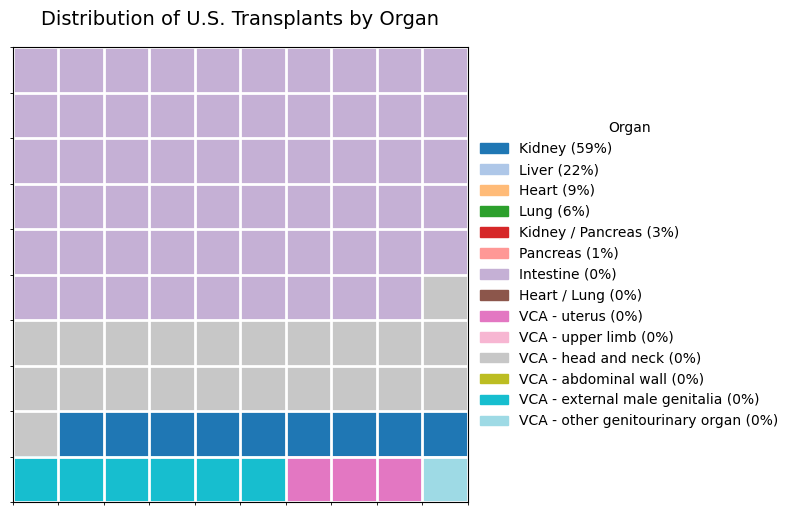

In [ ]:


# Aggregate total transplants by organ
organ_totals = (
    df.groupby("organ", as_index=False)["transplants"]
    .sum()
    .sort_values("transplants", ascending=False)
)

# Normalize to 100 waffle squares
organ_totals["squares"] = (
    organ_totals["transplants"] / organ_totals["transplants"].sum() * 100
).round().astype(int)

# Adjust rounding so total squares equals 100
difference = 100 - organ_totals["squares"].sum()
organ_totals.loc[organ_totals.index[0], "squares"] += difference

# Build 10x10 waffle grid
waffle_values = []
for i, row in organ_totals.iterrows():
    waffle_values.extend([i] * row["squares"])

waffle_grid = np.array(waffle_values).reshape(10, 10)

# Plot waffle chart
colors = {
    'Kidney': '#6f8f72',
    'Liver': '#7c9a92',
    'Heart': '#9c7a7a',
    'Lung': '#c2a878'
}
cmap = ListedColormap(colors)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(waffle_grid, cmap=cmap)

# Add grid lines
ax.set_xticks(np.arange(-0.5, 10, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 10, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)

ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Distribution of U.S. Transplants by Organ", fontsize=14, pad=16)

# Legend
handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors[i])
    for i in range(len(organ_totals))
]

labels = [
    f"{row['organ']} ({row['squares']}%)"
    for _, row in organ_totals.iterrows()
]

ax.legend(
    handles,
    labels,
    title="Organ",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()